<a href="https://colab.research.google.com/github/Meemansha-spec/Loan-Payback-Prediction/blob/main/Credit_risk_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Loan Prediction Dataset
In this prediction problem we have to find out what is the probability that the person will default.

`Loan poad - 1`
`Default - 0`

In this Notebook I am only going to do the EDA part, no prediction.Just studying the data



### First import all the necessary libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

### Import the dataset and study the data

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Credit Risk Analysis/loan_dataset_20000.csv')
df.head()

,age,gender,marital_status,education_level,annual_income,monthly_income,employment_status,debt_to_income_ratio,credit_score,loan_amount,...,loan_term,installment,grade_subgrade,num_of_open_accounts,total_credit_limit,current_balance,delinquency_history,public_records,num_of_delinquencies,loan_paid_back
0,59,Male,Married,Master's,24240.19,2020.02,Employed,0.074,743,17173.72,...,36,581.88,B5,7,40833.47,24302.07,1,0,1,1
1,72,Female,Married,Bachelor's,20172.98,1681.08,Employed,0.219,531,22663.89,...,60,573.17,F1,5,27968.01,10803.01,1,0,3,1
2,49,Female,Single,High School,26181.80,2181.82,Employed,0.234,779,3631.36,...,60,76.32,B4,2,15502.25,4505.44,0,0,0,1
3,35,Female,Single,High School,11873.84,989.49,Employed,0.264,809,14939.23,...,36,468.07,A5,7,18157.79,5525.63,4,0,5,1
4,63,Other,Single,Other,25326.44,2110.54,Employed,0.260,663,16551.71,...,60,395.50,D5,1,17467.56,3593.91,2,0,2,1


In [ ]:
print("Shape of dataset:  " , df.shape)
print("Number of duplicated rows:" , df.duplicated().sum())

Shape of dataset:   (20000, 22)
Number of duplicated rows: 0


In [ ]:
df['loan_paid_back'].value_counts()

,count
loan_paid_back,
1,15998
0,4002


In [ ]:
df.isna().sum()

,0
age,0
gender,0
marital_status,0
education_level,0
annual_income,0
monthly_income,0
employment_status,0
debt_to_income_ratio,0
credit_score,0
loan_amount,0


### Conclusions from the dataset
- Data is imbalanced
- There are no missing columns
- There are no duplicate columns
- Data has 6 categorical and 16 numerical columns
- Total 22 columns
- 1: Loan paid back
- 0: Default


# EDA - numerical plot

<Axes: xlabel='loan_paid_back', ylabel='count'>

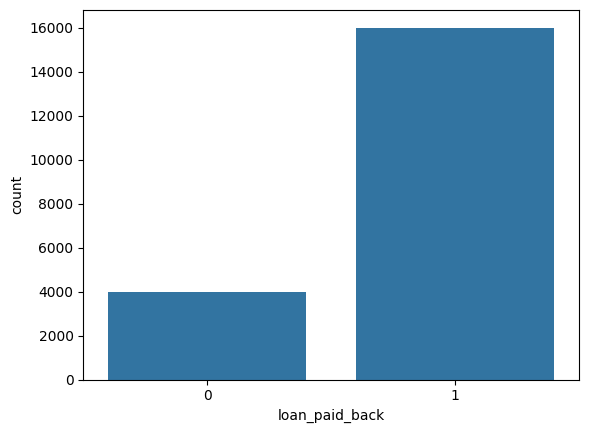

In [ ]:
sns.countplot(data = df , x = 'loan_paid_back')

<Axes: xlabel='annual_income', ylabel='Count'>

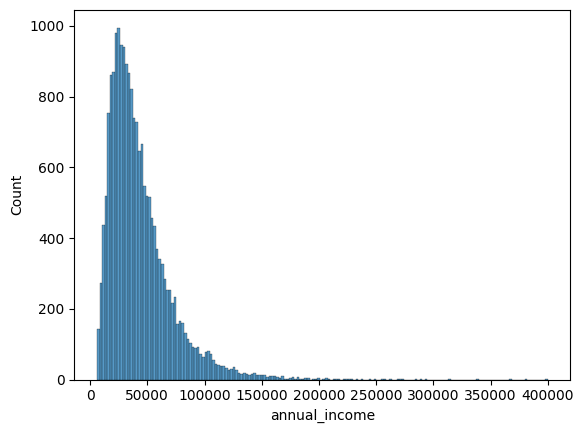

In [ ]:
sns.histplot(df['annual_income'])

In [ ]:

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, f1_score
)
from xgboost import XGBClassifier
import joblib

#### Split Data into training and testing

In [ ]:
X= df.drop('loan_paid_back',axis=1)
y= df['loan_paid_back']

In [ ]:
categorical_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
numerical_cols   = X.select_dtypes(include=["number"]).columns.tolist()

print(f"\nNumerical columns  ({len(numerical_cols)}) : {numerical_cols}")
print(f"Categorical columns({len(categorical_cols)}) : {categorical_cols}")


Numerical columns  (15) : ['age', 'annual_income', 'monthly_income', 'debt_to_income_ratio', 'credit_score', 'loan_amount', 'interest_rate', 'loan_term', 'installment', 'num_of_open_accounts', 'total_credit_limit', 'current_balance', 'delinquency_history', 'public_records', 'num_of_delinquencies']
Categorical columns(6) : ['gender', 'marital_status', 'education_level', 'employment_status', 'loan_purpose', 'grade_subgrade']


In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
print(f"\nTrain size: {X_train.shape[0]}  |  Test size: {X_test.shape[0]}")


Train size: 16000  |  Test size: 4000


STEP 4: PREPROCESSING PIPELINES
#####        - Numerical  : impute (median) → scale (StandardScaler)
#####        - Categorical: impute (most_frequent) → One-Hot Encode
##### ────────────────────────────────────────────────────────────────

In [ ]:
numerical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot",  OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numerical_transformer,   numerical_cols),
    ("cat", categorical_transformer, categorical_cols)
])

### Define Models

In [ ]:
models = {

    # ── Logistic Regression ──────────────────────────────────────────────────
    "Logistic Regression": {
        "estimator": LogisticRegression(max_iter=1000, random_state=42),
        "params": {
            "classifier__C":       [0.01, 0.1, 1, 10, 100],
            "classifier__penalty": ["l1", "l2"],
            "classifier__solver":  ["liblinear", "saga"],
        }
    },

    # ── Random Forest ────────────────────────────────────────────────────────
    "Random Forest": {
        "estimator": RandomForestClassifier(random_state=42),
        "params": {
            "classifier__n_estimators":      [100, 200, 300],
            "classifier__max_depth":         [None, 10, 20, 30],
            "classifier__min_samples_split": [2, 5, 10],
            "classifier__min_samples_leaf":  [1, 2, 4],
            "classifier__max_features":      ["sqrt", "log2"],
        }
    },

    # ── XGBoost ──────────────────────────────────────────────────────────────
    "XGBoost": {
        "estimator": XGBClassifier(
            eval_metric="logloss", use_label_encoder=False, random_state=42
        ),
        "params": {
            "classifier__n_estimators":  [100, 200, 300],
            "classifier__max_depth":     [3, 5, 7, 9],
            "classifier__learning_rate": [0.01, 0.05, 0.1, 0.2],
            "classifier__subsample":     [0.7, 0.8, 1.0],
            "classifier__colsample_bytree": [0.7, 0.8, 1.0],
            "classifier__reg_alpha":     [0, 0.1, 0.5],
            "classifier__reg_lambda":    [1, 1.5, 2],
        }
    },

    # ── AdaBoost ─────────────────────────────────────────────────────────────
    "AdaBoost": {
        "estimator": AdaBoostClassifier(random_state=42),
        "params": {
            "classifier__n_estimators":  [50, 100, 200],
            "classifier__learning_rate": [0.01, 0.1, 0.5, 1.0],
            "classifier__algorithm":     ["SAMME", "SAMME.R"],
        }
    },
}

## Hyperparameter Tuning

In [ ]:
cv         = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results    = {}
best_model = None
best_score = 0.0

for name, config in models.items():
    print("\n" + "=" * 60)
    print(f"  {name.upper()}")
    print("=" * 60)

    # Build full pipeline: preprocessor → classifier
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier",   config["estimator"])
    ])

    # Grid search with cross-validation
    grid_search = GridSearchCV(
        estimator  = pipe,
        param_grid = config["params"],
        cv         = cv,
        scoring    = "f1_weighted",   # change to "roc_auc" for binary tasks
        n_jobs     = -1,
        verbose    = 1,
        refit      = True
    )

    grid_search.fit(X_train, y_train)

    # Evaluate on held-out test set
    y_pred   = grid_search.best_estimator_.predict(X_test)
    acc      = accuracy_score(y_test, y_pred)
    f1       = f1_score(y_test, y_pred, average="weighted")

    try:
        y_prob  = grid_search.best_estimator_.predict_proba(X_test)
        n_cls   = len(np.unique(y_test))
        auc     = roc_auc_score(
            y_test, y_prob,
            multi_class="ovr" if n_cls > 2 else "raise",
            average="weighted"
        )
    except Exception:
        auc = None

    results[name] = {
        "best_params":  grid_search.best_params_,
        "cv_score":     grid_search.best_score_,
        "test_acc":     acc,
        "test_f1":      f1,
        "test_auc":     auc,
        "best_model":   grid_search.best_estimator_,
    }

    print(f"\n  Best CV F1      : {grid_search.best_score_:.4f}")
    print(f"  Test Accuracy   : {acc:.4f}")
    print(f"  Test F1 (wtd)   : {f1:.4f}")
    if auc:
        print(f"  Test ROC-AUC    : {auc:.4f}")
    print(f"\n  Best Params:")
    for k, v in grid_search.best_params_.items():
        print(f"    {k}: {v}")
    print(f"\n  Classification Report:\n{classification_report(y_test, y_pred)}")

    # Track overall best model
    if f1 > best_score:
        best_score = f1
        best_model = (name, grid_search.best_estimator_)



  LOGISTIC REGRESSION
Fitting 5 folds for each of 20 candidates, totalling 100 fits

  Best CV F1      : 0.8833
  Test Accuracy   : 0.8900
  Test F1 (wtd)   : 0.8780

  Best Params:
    classifier__C: 0.01
    classifier__penalty: l2
    classifier__solver: liblinear

  Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.52      0.66       818
           1       0.89      0.99      0.93      3182

    accuracy                           0.89      4000
   macro avg       0.90      0.75      0.80      4000
weighted avg       0.89      0.89      0.88      4000


  RANDOM FOREST
Fitting 5 folds for each of 216 candidates, totalling 1080 fits

  Best CV F1      : 0.8891
  Test Accuracy   : 0.8945
  Test F1 (wtd)   : 0.8827

  Best Params:
    classifier__max_depth: 30
    classifier__max_features: sqrt
    classifier__min_samples_leaf: 1
    classifier__min_samples_split: 2
    classifier__n_estimators: 200

  Classification Report:
 

In [ ]:
print("\n" + "=" * 60)
print("  FINAL COMPARISON SUMMARY")
print("=" * 60)
summary_rows = []
for name, r in results.items():
    summary_rows.append({
        "Model":        name,
        "CV F1":        round(r["cv_score"],  4),
        "Test Acc":     round(r["test_acc"],   4),
        "Test F1":      round(r["test_f1"],    4),
        "ROC-AUC":      round(r["test_auc"],   4) if r["test_auc"] else "N/A",
    })

summary_df = pd.DataFrame(summary_rows).sort_values("Test F1", ascending=False)
print(summary_df.to_string(index=False))

print(f"\n🏆  Best overall model : {best_model[0]}  (F1 = {best_score:.4f})")

In [ ]:
joblib.dump(best_model[1], "best_model.pkl")
print(f"\n✅  Best model saved to  →  best_model.pkl")

In [ ]:
loaded_model = joblib.load("best_model.pkl")
# predictions  = loaded_model.predict(new_data_df)
# probabilities = loaded_model.predict_proba(new_data_df)
